<div style="text-align:center;">
    <h3>Introduction to Machine Learning</h3>
</div>
<div style="text-align:center;">
    <h4> Assignment 3/ Project </h4>
</div>
<div style="text-align:center;">
    <span style="font-size: 20px; background-color:pink; color:black;">
        Image Caption Generation
    </span>
</div>

Team Members:
- Jahnavi Agrawal (1020231300)
- Neha Palak (1020231795)




## <span style="background-color:yellow; color:black">TASK 1: Introduction</span>

***

The ArtEmis dataset is a large-scale collection of artwork images from WikiArt, each paired with human-written captions that describe not only the visual content but also the emotional and interpretive aspects of art. It connects visual understanding with human affective responses, making it ideal for studying image caption generation that goes beyond object recognition.

The goal of this project is to <u>generate meaningful captions for artworks</u> using two different deep learning approaches:

* **CNN + LSTM model**: trained from scratch to extract image features and generate captions word-by-word.
* **Vision–Language Transformer**: model that jointly learns image and text representations for caption generation.

This task also involves a <u>comparison of text embeddings and sequence modeling methods</u>, such as TF-IDF, Word2Vec, GloVe, and FastText, to understand how different embedding strategies affect caption fluency and quality.


***

## <span style="background-color:yellow; color:black">TASK 2: Exploratory Data Analysis (EDA)</span>

***



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("artemis_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454684 entries, 0 to 454683
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   art_style   454684 non-null  object
 1   painting    454684 non-null  object
 2   emotion     454684 non-null  object
 3   utterance   454684 non-null  object
 4   repetition  454684 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 17.3+ MB


In [3]:
df.head()

,art_style,painting,emotion,utterance,repetition
0,Post_Impressionism,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,something else,"She seems very happy in the picture, and you w...",10
1,Post_Impressionism,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,sadness,This woman has really knotty hands which makes...,10
2,Post_Impressionism,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,something else,"When looking at this woman, I am filled with c...",10
3,Post_Impressionism,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,contentment,"A woman looking at ease, peaceful, and satisfi...",10
4,Post_Impressionism,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,awe,She looks like a lady from that past that migh...,10


In [4]:
# Basic stats
print("num rows:", len(df))
print("unique paintings:", df['painting'].nunique())
print()
print("captions per painting (describe):")
print(df.groupby('painting').size().describe())

num rows: 454684
unique paintings: 80031

captions per painting (describe):
count    80031.000000
mean         5.681348
std          4.025648
min          5.000000
25%          5.000000
50%          5.000000
75%          5.000000
max         58.000000
dtype: float64


In [5]:
# repetition column quick look
print("unique repetition values:", df['repetition'].unique())

unique repetition values: [10  7  6 11  8 12 48 47 45 50 49 52 13 46 51  5 43 54 53 58 55 44 56  9
 42 57 41]


Some paintings have multiple captions ranging from 5 to 60!

In [6]:
print(df[['utterance','repetition']].head(10))

                                           utterance  repetition
0  She seems very happy in the picture, and you w...          10
1  This woman has really knotty hands which makes...          10
2  When looking at this woman, I am filled with c...          10
3  A woman looking at ease, peaceful, and satisfi...          10
4  She looks like a lady from that past that migh...          10
5  The bright colors make a very unique scene for...           7
6  The way the image is presented, with large chu...           7
7  the stroke of blue paint used to outline the h...           7
8  Some of the wooden panels are falling from the...           7
9  The golden gloves and white dress stand out an...           7


In [7]:
caption_counts = df.groupby('painting').size()
caption_counts.describe()

count    80031.000000
mean         5.681348
std          4.025648
min          5.000000
25%          5.000000
50%          5.000000
75%          5.000000
max         58.000000
dtype: float64

Average count of captions is 5 for each painting. 

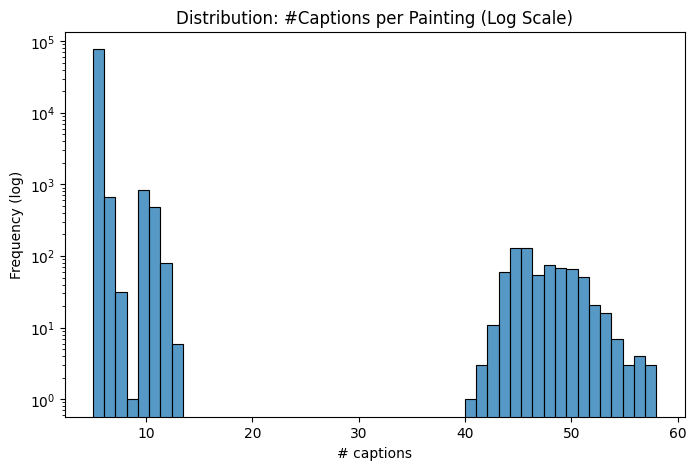

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(caption_counts, bins=50)
plt.yscale("log")
plt.title("Distribution: #Captions per Painting (Log Scale)")
plt.xlabel("# captions")
plt.ylabel("Frequency (log)")
plt.show()

Most paintings have 5–7 affective explanations, with a mean of ~5.68. A small subset (<1%) has 40+ captions because these artworks were shown to more annotators. The distribution is highly skewed, so we visualize the main region (0–15 captions) separately and use log scaling to examine the tail.


* Caption Length

In [9]:
df['token_count'] = df['utterance'].str.split().apply(len)
df['token_count'].describe()

count    454684.000000
mean         15.685533
std           7.946779
min           1.000000
25%          11.000000
50%          14.000000
75%          18.000000
max         202.000000
Name: token_count, dtype: float64

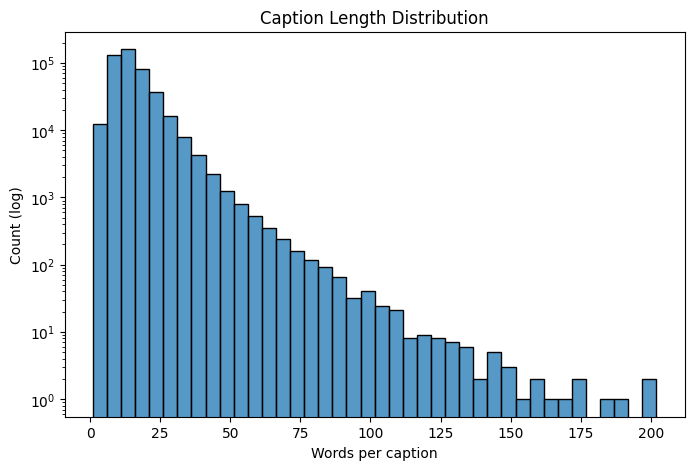

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['token_count'], bins=40)
plt.yscale("log")
plt.title("Caption Length Distribution")
plt.xlabel("Words per caption")
plt.ylabel("Count (log)")
plt.show()

In [11]:
df['token_count'].quantile([0.5, 0.75, 0.90, 0.95, 0.99])

0.50    14.0
0.75    18.0
0.90    25.0
0.95    30.0
0.99    45.0
Name: token_count, dtype: float64

The caption length distribution shows that most explanations in the ArtEmis dataset are relatively short and compact, with half of them containing 14 words or fewer and 75% staying under 18 words. However, there is a noticeable long-tail pattern where some annotators provide much longer, more detailed emotional responses, with the longest 1% reaching up to around 45 words. Because of this imbalance, the model needs a fixed padded sequence length that is long enough to avoid cutting off meaningful content from longer captions while still keeping computation efficient. A sequence length of about 25 tokens strikes this balance well, capturing over 90% of captions without excessive padding.


* Emotion Distribution

In [12]:
emotion_counts = df['emotion'].value_counts()
emotion_counts

emotion
contentment       126134
awe                72927
something else     52962
sadness            49061
amusement          45336
fear               41577
excitement         37636
disgust            22411
anger               6640
Name: count, dtype: int64

In [13]:
positive_emotions = {'contentment', 'awe', 'amusement', 'excitement'}
negative_emotions = {'sadness', 'fear', 'disgust', 'anger'}

# Map emotions to sentiment
def label_sentiment(emotion):
    if emotion in positive_emotions:
        return 'positive'
    elif emotion in negative_emotions:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['emotion'].apply(label_sentiment)
print(df['sentiment'].value_counts())

sentiment
positive    282033
negative    119689
neutral      52962
Name: count, dtype: int64


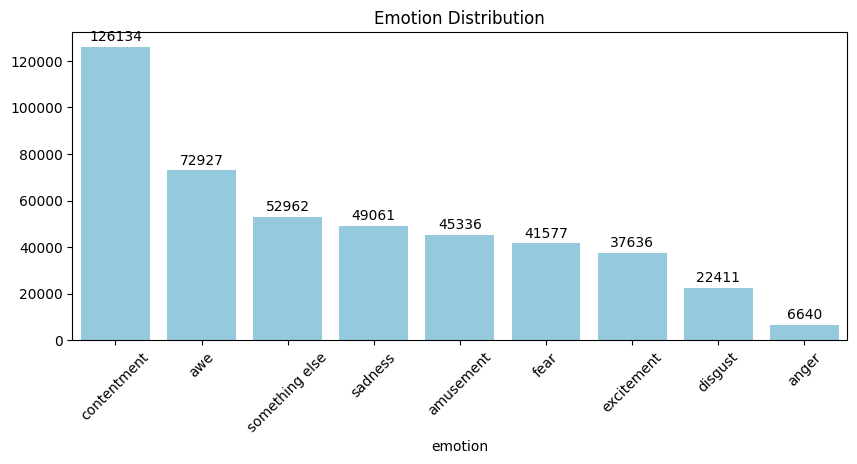

In [14]:
plt.figure(figsize=(10,4))
ax = sns.barplot(x=emotion_counts.index, 
                 y=emotion_counts.values, 
                 color='skyblue')

plt.title("Emotion Distribution")
plt.xticks(rotation=45)

# Add values on top of each bar
for i, v in enumerate(emotion_counts.values):
    ax.text(i, v + (0.01 * max(emotion_counts.values)),   # small offset above bar
            str(v), 
            ha='center', va='bottom', fontsize=10)

plt.show()


The emotion distribution in the ArtEmis dataset is highly imbalanced. Contentment is by far the most common emotion, with over 126k annotations, followed by awe (~73k) and “something else” (~53k). Mid-frequency emotions include sadness, amusement, fear, and excitement, each ranging between 37k–49k examples. In contrast, negative emotions such as disgust (~22k) and especially anger (~6.6k) are relatively rare. This skew suggests that the dataset primarily reflects positive or neutral affect, which may bias models to generate less emotionally intense captions unless balanced or weighted appropriately.

* Art Style Distribution

In [15]:
style_counts = df['art_style'].value_counts()
style_counts

art_style
Impressionism                 72361
Realism                       59681
Romanticism                   39069
Expressionism                 38717
Post_Impressionism            36374
Art_Nouveau_Modern            24711
Symbolism                     24103
Baroque                       23469
Abstract_Expressionism        16075
Northern_Renaissance          14160
Naive_Art_Primitivism         14086
Rococo                        11904
Cubism                        11462
Color_Field_Painting           9836
Pop_Art                        8438
Early_Renaissance              7622
High_Renaissance               7366
Minimalism                     7163
Mannerism_Late_Renaissance     7047
Ukiyo_e                        6615
Fauvism                        4191
Contemporary_Realism           2953
Pointillism                    2870
New_Realism                    1848
Synthetic_Cubism               1284
Action_painting                 664
Analytical_Cubism               615
Name: count, dtype

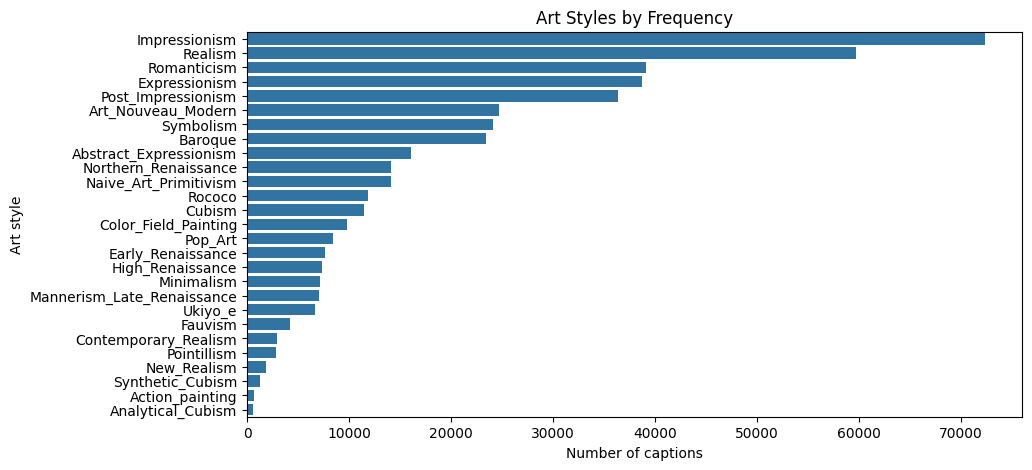

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(y=style_counts.index, x=style_counts.values)
plt.title("Art Styles by Frequency")
plt.xlabel("Number of captions")
plt.ylabel("Art style")
plt.show()

The art style distribution is highly imbalanced, with a few styles dominating the dataset. Impressionism, Realism, and Romanticism have the largest number of captions, while many other styles appear far less frequently. This long-tailed pattern shows that the dataset is rich but uneven, with certain art movements far more represented than others.


* Repetition Columns

In [17]:
df['repetition'].value_counts().sort_index()
df[['painting','utterance','repetition']].head(20)

,painting,utterance,repetition
0,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,"She seems very happy in the picture, and you w...",10
1,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,This woman has really knotty hands which makes...,10
2,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,"When looking at this woman, I am filled with c...",10
3,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,"A woman looking at ease, peaceful, and satisfi...",10
4,vincent-van-gogh_portrait-of-madame-ginoux-l-a...,She looks like a lady from that past that migh...,10
5,wassily-kandinsky_study-for-autumn-1909,The bright colors make a very unique scene for...,7
6,wassily-kandinsky_study-for-autumn-1909,"The way the image is presented, with large chu...",7
7,konstantin-korovin_yaroslavna-s-lament-1909,the stroke of blue paint used to outline the h...,7
8,konstantin-korovin_yaroslavna-s-lament-1909,Some of the wooden panels are falling from the...,7
9,paul-gauguin_mette-gauguin-in-an-evening-dress...,The golden gloves and white dress stand out an...,7


In [18]:
df_unique = df.drop_duplicates(subset=['painting','utterance'])

In [19]:
df.sample(10)

,art_style,painting,emotion,utterance,repetition,token_count,sentiment
365765,Realism,pyotr-konchalovsky_in-the-woods-1945,contentment,the trees and colors blend well with the blue sky,5,10,positive
164871,Romanticism,ferdinand-georg-waldmã¼ller_old-elms-in-prater...,excitement,The trees are so lifelike and the colors used ...,5,15,positive
170949,Naive_Art_Primitivism,fernand-leger_composition-in-two-birds-landsca...,awe,The birds look very happy and colorful.,5,7,positive
399834,Impressionism,giuseppe-de-nittis_rue-de-paris-with-carriages,excitement,the bright color of the bricks made them look ...,6,11,positive
215401,Post_Impressionism,le-pho_woman-on-the-balcony-1938,contentment,The woman's transparent veil and delicate expr...,6,11,positive
397446,Realism,vincent-van-gogh_the-parsonage-garden-at-nuene...,sadness,This painting makes me sad as it seems that th...,5,17,negative
12297,Impressionism,camille-pissarro_a-part-of-jallais-pontoise-1875,contentment,A woman walks on the shadowy hill while in the...,5,16,positive
280317,Expressionism,candido-portinari_menino-com-p-ssaro-1957,sadness,"the poor bird looks injured, but it being tend...",5,10,negative
307393,Post_Impressionism,vincent-van-gogh_moulin-de-la-galette-1886,excitement,I like how mysterious this looks. Makes you wo...,5,16,positive
14988,Naive_Art_Primitivism,marc-chagall_tamar-beautiful-daughter-of-judah...,disgust,The image is weird and boring and lacks contex...,5,11,negative


In [20]:
from collections import Counter
import re

def clean(text):
    return re.sub(r"[^a-zA-Z ]","",text.lower()).split()

words = Counter()
df['utterance'].sample(20000).apply(lambda s: words.update(clean(s)))

words.most_common(20) 

[('the', 29015),
 ('and', 11284),
 ('a', 10413),
 ('of', 9259),
 ('is', 7874),
 ('to', 5815),
 ('in', 5466),
 ('like', 5286),
 ('this', 5073),
 ('i', 4373),
 ('it', 4186),
 ('looks', 4053),
 ('me', 3264),
 ('are', 3082),
 ('on', 2834),
 ('with', 2627),
 ('look', 2112),
 ('very', 2098),
 ('painting', 2084),
 ('colors', 2060)]

In [21]:
import pandas as pd

df = pd.read_csv("new_preprocessed/artemis_preprocessed.csv")
print("Unique paintings:", df['painting'].nunique())
print("Total rows:", len(df))

Unique paintings: 5500
Total rows: 28060


***

## <span style="background-color:yellow; color:black">TASK 3: Preprocessing</span>

***



Our preprocessing prepares the ArtEmis dataset for training by cleaning text, tokenizing captions, normalizing images, constructing a vocabulary, and creating train/val/test splits.

1. Text Cleaning : Convert captions to lowercase, remove non-alphanumeric characters, remove extra spaces 

2. Tokenization (spaCy): Use spaCy to split text into tokens, generates clean token lists for each caption 

3. Dataset Subsampling was done due to computational capacities: We practiced stratified sampling by art style to preserve distribution (ratio of images per art style) (total 5500 unique images.)

4. Emotion Mapping: convert emotion strings into numeric labels (0–8)

5. Image Processing: copy and resize to a 128 size and convert to normalized. 

6. Length Filtering: remove very short or very long captions 

7. Painting-Level Split: Train/validation/test (80/10/10) split performed by painting to prevents data leakage across splits

8. Vocabulary Construction: Built only from training tokens and it includes four special tokens with (Max vocab= 8000)

9. Token ID Encoding: Convert tokens to integer IDs, Pad/truncate to a fixed length for model training

PS: We tried different methods of tokenizing:

* We used BERT (which tokenizes according to subwords), subtokenizing using prefixes and suffixes, only to learn that TF-IDF and other pre-trained embedding models which have their own vocabulary, will not be implementable. So, we opted for a manual tokenizing technique that tokenizes according to white spaces between the words. 
Later, we switched to Spacy for tokenizing. 

In [ ]:
# verifying number of subsampled images

import os

path = "new_preprocessed/images_subset"
counts = []

for root, dirs, files in os.walk(path):
    counts.append((root, len(files)))

# sort by count descending
counts = sorted(counts, key=lambda x: x[1], reverse=True)

for folder, count in counts:
    print(f"{folder}: {count} files")

total = sum(count for _, count in counts)
print("\nTotal file count:", total)

new_preprocessed/images_subset: 5500 files

Total file count: 5500


In [2]:
# loading vocab.pkl

import pickle

file_path = 'new_preprocessed/vocab.pkl'
with open(file_path, 'rb') as f:
    data = pickle.load(f)

print(data)

{'<pad>': 0, '<start>': 1, '<end>': 2, '<unk>': 3, 'the': 4, 'and': 5, 'a': 6, 'of': 7, 'is': 8, 'to': 9, 'like': 10, 'in': 11, 'this': 12, 'it': 13, 'looks': 14, 'i': 15, 'me': 16, 'are': 17, 'on': 18, 'with': 19, "'s": 20, 'look': 21, 'colors': 22, 'painting': 23, 'very': 24, 'makes': 25, 'man': 26, 'feel': 27, 'woman': 28, 'that': 29, 'her': 30, 'be': 31, 'at': 32, 'as': 33, 'for': 34, 'she': 35, 'he': 36, 'so': 37, 'they': 38, 'his': 39, 'but': 40, 'make': 41, 'an': 42, 'people': 43, 'has': 44, 'face': 45, 'dark': 46, 'seems': 47, 'there': 48, 'scene': 49, 'beautiful': 50, 'out': 51, 'not': 52, 'color': 53, 'picture': 54, 'looking': 55, 'by': 56, 'from': 57, 'love': 58, 'what': 59, 'white': 60, 'blue': 61, 'because': 62, 'or': 63, 'sad': 64, 'all': 65, 'bright': 66, 'red': 67, 'just': 68, 'way': 69, 'water': 70, 'about': 71, 'black': 72, "n't": 73, 'something': 74, 'sky': 75, 'have': 76, 'reminds': 77, 'background': 78, 'happy': 79, 'peaceful': 80, 'seem': 81, 'really': 82, 'how': 

In [3]:
# verifying size of subsampled images (128x128)
from PIL import Image
import os

root = "new_preprocessed/images_subset" 

total = 0
wrong = []

for subdir, _, files in os.walk(root):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            total += 1
            path = os.path.join(subdir, f)
            try:
                img = Image.open(path)
                if img.size != (128, 128):
                    wrong.append(path)
            except:
                wrong.append(path)

print("Total images checked:", total)
print("Images NOT 128x128:", len(wrong))

if wrong:
    print("First few incorrect images:")
    for w in wrong[:10]:
        print(" -", w)


Total images checked: 5500
Images NOT 128x128: 0


In [5]:
# number of paintings per art style after preprocessing

import pandas as pd
df = pd.read_csv("new_preprocessed/artemis_preprocessed.csv")

counts = df.drop_duplicates(['art_style','painting'])['art_style'].value_counts()

print(counts)


art_style
Impressionism                 903
Realism                       747
Expressionism                 481
Romanticism                   462
Post_Impressionism            450
Art_Nouveau_Modern            287
Baroque                       278
Symbolism                     272
Northern_Renaissance          184
Abstract_Expressionism        184
Naive_Art_Primitivism         146
Rococo                        134
Color_Field_Painting          125
Cubism                        122
Early_Renaissance             105
Ukiyo_e                        97
Mannerism_Late_Renaissance     91
Pop_Art                        89
High_Renaissance               84
Minimalism                     82
Fauvism                        63
Pointillism                    38
Contemporary_Realism           29
New_Realism                    19
Synthetic_Cubism               16
Action_painting                 6
Analytical_Cubism               6
Name: count, dtype: int64


In [7]:
# verifying pixel normalization

import os
import numpy as np
import random

FEATURES_DIR = "new_preprocessed/features"

global_min = 1e9
global_max = -1e9

for root, dirs, files in os.walk(FEATURES_DIR):
    for f in files:
        if f.endswith(".npy"):
            arr = np.load(os.path.join(root, f))
            global_min = min(global_min, arr.min())
            global_max = max(global_max, arr.max())

print("GLOBAL MIN:", global_min)
print("GLOBAL MAX:", global_max)


all_feats = []
for root, dirs, files in os.walk(FEATURES_DIR):
    for f in files:
        if f.endswith(".npy"):
            all_feats.append(os.path.join(root, f))

for f in random.sample(all_feats, 5):
    arr = np.load(f)
    print(f, "-> min:", arr.min(), "max:", arr.max())



GLOBAL MIN: 0.0
GLOBAL MAX: 1.0
new_preprocessed/features/claude-monet_dahlias.npy -> min: 0.0 max: 0.98039216
new_preprocessed/features/pablo-picasso_a-rooster-1938.npy -> min: 0.12941177 max: 1.0
new_preprocessed/features/cornelis-springer_view-of-oudewater.npy -> min: 0.003921569 max: 0.9607843
new_preprocessed/features/cornelis-springer_a-view-of-the-south-entrance-of-the-st-pancras-church-enkhuizen-1869.npy -> min: 0.011764706 max: 1.0
new_preprocessed/features/antoine-blanchard_place-de-la-concorde-1.npy -> min: 0.0 max: 0.99607843


In [20]:
#checking for empty captions

import pandas as pd

df = pd.read_csv("new_preprocessed/artemis_preprocessed.csv")

# Count missing (NaN) or empty strings
empty_count = df['utter_clean'].isna().sum() + (df['utter_clean'].str.strip() == "").sum()
print(f"Number of empty utter_clean entries: {empty_count}")


Number of empty utter_clean entries: 0


In [18]:
# verifying if there is any mismatch in the paintings in images subset and preprocessed dataset
import pandas as pd
from pathlib import Path

df = pd.read_csv("new_preprocessed/artemis_preprocessed.csv")
images_dir = Path("new_preprocessed/images_subset")

missing_images = []
for painting in df['painting'].unique():
    if not (images_dir / f"{painting}.jpg").exists():
        missing_images.append(painting)

print(f"Number of paintings missing image files: {len(missing_images)}")
print(missing_images[:10])  # show first 10 missing


Number of paintings missing image files: 0
[]


***

## <span style="background-color:yellow; color:black">TASK 4: Text Representation</span>

***



* The mew_representation.py script generates text embeddings using three strategies: TF-IDF with SVD, GloVe, and FastText.

* **TF-IDF + Dimensionality Reduction (SVD)**:

  * It calculates the Term Frequency-Inverse Document Frequency (TF-IDF) for the training text data.
  * Then, dimensionality reduction is applied using Singular Value Decomposition (SVD) to reduce the feature space.
  * The TF-IDF vectorizer, the SVD model, and also the reduced vectors for each dataset split (train/val/test) are saved.


* **Pre-trained Embeddings (GloVe & FastText)**:

  * GloVe and FastText pre-trained embeddings are loaded for the tokens found in the dataset's vocabulary.
  * Each word's vector is mapped to its token index, and an embedding matrix is built.
  * Coverage statistics are calculated: token-level coverage (how many vocabulary words have embeddings) and occurrence coverage (how many times the words appear in the training data).
  * The final embeddings for both GloVe and FastText are saved.

* **Outputs**:

  * The embeddings (GloVe, FastText) are saved in `.npy` format.
  * The TF-IDF vectorizer and SVD model are saved as `.pkl` files.
  * A summary of the embeddings (coverage stats, found tokens) is stored in a JSON file.

In [8]:
import pickle

file_path_1 = 'new_preprocessed/tfidf_svd.pkl'
with open(file_path_1, 'rb') as f:
    data = pickle.load(f)

print(data)

TruncatedSVD(n_components=2084, random_state=42)


/Users/nehapalak/.pyenv/versions/3.9.13/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [9]:
import pickle

file_path_2 = 'new_preprocessed/tfidf_vectorizer.pkl'
with open(file_path_2, 'rb') as f:
    data = pickle.load(f)

print(data)

TfidfVectorizer(max_features=20000)


/Users/nehapalak/.pyenv/versions/3.9.13/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/nehapalak/.pyenv/versions/3.9.13/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [10]:
import numpy as np

data = np.load('new_preprocessed/emb_glove_300d.npy')

print(data)

print(f"Shape: {data.shape}")
print(f"Data type: {data.dtype}")

[[ 0.2980285  -0.08295858  0.38861313 ...  0.18437971  0.48771727
   0.3777773 ]
 [-0.497397   -0.33610862  0.44837615 ... -0.5872582  -0.26657596
   0.22638029]
 [ 0.45419317 -0.5532992   0.52176356 ...  0.08802821  0.7239054
  -0.4901614 ]
 ...
 [-0.11409     0.21917     0.013243   ...  0.86692    -0.26118
  -0.23184   ]
 [-0.064791    0.10419    -0.021027   ...  0.44002    -0.034843
   0.046538  ]
 [ 0.15391156  0.18283813 -0.10597575 ... -0.23754786  1.4811382
  -0.15535454]]
Shape: (9901, 300)
Data type: float32


In [11]:
import numpy as np

data1 = np.load('new_preprocessed/emb_fasttext_300d.npy')

print(data1)

print(f"Shape: {data1.shape}")
print(f"Data type: {data1.dtype}")

[[ 2.9802850e-01 -8.2958579e-02  3.8861313e-01 ...  1.8437971e-01
   4.8771727e-01  3.7777731e-01]
 [-4.9739701e-01 -3.3610862e-01  4.4837615e-01 ... -5.8725822e-01
  -2.6657596e-01  2.2638029e-01]
 [ 4.5419317e-01 -5.5329919e-01  5.2176356e-01 ...  8.8028215e-02
   7.2390538e-01 -4.9016139e-01]
 ...
 [ 2.2200000e-02  2.4700001e-02  6.6000000e-03 ... -1.9000000e-03
   8.0000004e-03 -1.1300000e-02]
 [ 5.7999999e-03 -1.4500000e-02  1.1000000e-02 ...  5.0000002e-04
  -1.8999999e-02 -1.5400000e-02]
 [ 1.5391156e-01  1.8283813e-01 -1.0597575e-01 ... -2.3754786e-01
   1.4811382e+00 -1.5535454e-01]]
Shape: (9901, 300)
Data type: float32


In [13]:
df = pd.read_csv("new_preprocessed/artemis_preprocessed.csv")
df['tokens_len'].value_counts().sort_index()


tokens_len
3       64
4      141
5      225
6      395
7      667
8     1220
9     1808
10    2294
11    2546
12    2556
13    2390
14    2222
15    1944
16    1725
17    1437
18    1293
19    1102
20     951
21     886
22     681
23     556
24     533
25     424
Name: count, dtype: int64

In [15]:
print("Min token length:", df['tokens_len'].min())
print("Max token length:", df['tokens_len'].max())


Min token length: 3
Max token length: 25


In [23]:
# checking vocab 

def load_vocab(vocab_path):
    """
    Load vocab.pkl that can be:
      - dict mapping token -> idx
      - object with .token_to_idx attribute
      - list/tuple of tokens

    Returns:
      token_to_idx (dict), idx2token (dict), pad_idx, sos_idx, eos_idx

    Pads/defaults: if <pad>/<start>/<end> missing, falls back to sensible defaults.
    """
    import pickle
    from pathlib import Path

    p = Path(vocab_path)
    if not p.exists():
        raise FileNotFoundError(f"vocab file not found: {vocab_path}")

    with open(p, "rb") as f:
        obj = pickle.load(f)

    # Determine mapping token->idx
    if isinstance(obj, dict):
        token_to_idx = obj
    elif hasattr(obj, "token_to_idx"):
        token_to_idx = obj.token_to_idx
    elif isinstance(obj, (list, tuple)):
        token_to_idx = {t: i for i, t in enumerate(obj)}
    else:
        # try common fallback: maybe pickle of an object that stores mapping as attribute
        if hasattr(obj, "vocab") and isinstance(obj.vocab, dict):
            token_to_idx = obj.vocab
        else:
            raise RuntimeError("Unrecognized vocab.pkl contents. Expected dict or object with token_to_idx/list of tokens.")

    # build reverse map
    idx2token = {i: t for t, i in token_to_idx.items()}

    # resolve indices for pad/start/end
    def find_idx(names, default):
        for n in names:
            if n in token_to_idx:
                return token_to_idx[n]
        return default

    # common defaults if tokens not present
    pad_idx = find_idx(["<pad>", "<PAD>", "[PAD]"], 0)
    sos_idx = find_idx(["<start>", "<s>", "<START>"], 1)
    eos_idx = find_idx(["<end>", "</s>", "<END>"], 2)

    return token_to_idx, idx2token, pad_idx, sos_idx, eos_idx

token_to_idx, idx2token, pad_idx, sos_idx, eos_idx = load_vocab("new_preprocessed/vocab.pkl")
print("vocab size:", len(token_to_idx))
print("<pad> idx:", pad_idx, "<start> idx:", sos_idx, "<end> idx:", eos_idx)
# show a few tokens
for i in range(10):
    print(i, idx2token.get(i, "<missing>"))

vocab size: 9901
<pad> idx: 0 <start> idx: 1 <end> idx: 2
0 <pad>
1 <start>
2 <end>
3 <unk>
4 the
5 and
6 a
7 of
8 is
9 to


In [27]:
import pandas as pd, numpy as np, pickle

df = pd.read_csv("new_preprocessed/artemis_preprocessed.csv")
tok2idx = pickle.load(open("new_preprocessed/vocab.pkl","rb"))
pad_idx = tok2idx.get("<pad>", 0)

def parse_ids(s):
    if isinstance(s, str) and s.startswith("[") and s.endswith("]"):
        return [int(x) for x in eval(s)]
    if isinstance(s, str):
        return [int(x) for x in s.split()]
    return list(s)

lens = []
pad_counts = 0
total_tokens = 0
for s in df['token_ids_with_emotion_str'].astype(str):
    ids = parse_ids(s)
    nonpad = sum(1 for i in ids if i != pad_idx)
    pads = sum(1 for i in ids if i == pad_idx)
    lens.append(nonpad)
    pad_counts += pads
    total_tokens += len(ids)

print("rows:", len(df))
print("avg non-pad token length:", np.mean(lens))
print("median non-pad length:", np.median(lens))
print("pad tokens total:", pad_counts, "total tokens:", total_tokens, "pad_pct:", pad_counts/total_tokens)

rows: 28060
avg non-pad token length: 16.996899501069137
median non-pad length: 16.0
pad tokens total: 224567 total tokens: 701500 pad_pct: 0.3201240199572345


***

## <span style="background-color:yellow; color:black">TASK 5: Models</span>

***

* codes are saved as .py files in scripts folder
* every explanation is mentioned in the report

***

## <span style="background-color:yellow; color:black">TASK 6: Training and Evaluation</span>

***



In [29]:
%matplotlib inline

import sys
import importlib

# Ensure Jupyter sees the project directory
sys.path.append(".")

# Import the visualiser
import scripts.attention_visualiser as attention_visualiser

# Reload so edits reflect immediately
importlib.reload(attention_visualiser)

<module 'scripts.attention_visualiser' from '/Users/nehapalak/cs3410/IML_A3/scripts/attention_visualiser.py'>

Loading model from new_checkpoints/glove/m2_glove_best.pt


/Users/nehapalak/.pyenv/versions/3.9.13/lib/python3.9/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Generated caption: the trees are so dark and the trees are very gloomy

Visualizing attention maps...
  Word 0: the


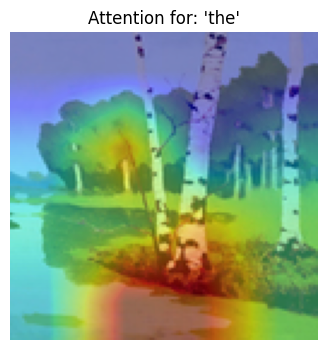

  Word 1: trees


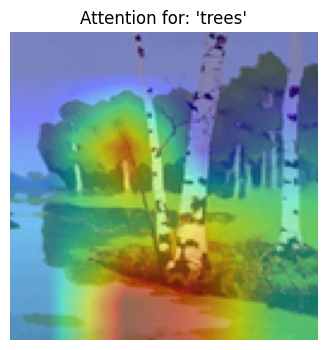

  Word 2: are


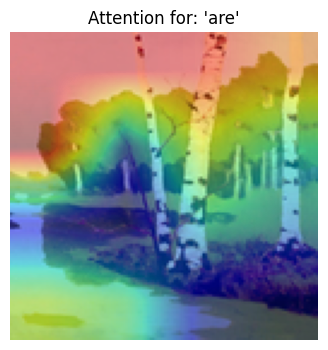

  Word 3: so


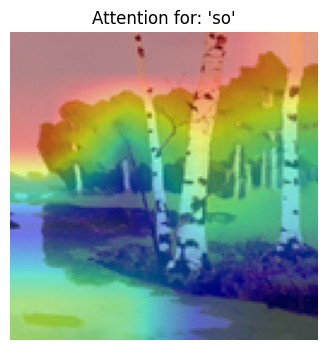

  Word 4: dark


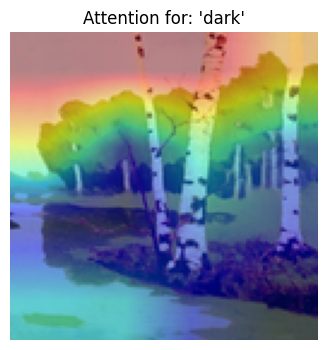

  Word 5: and


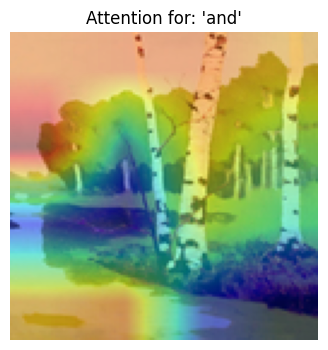

  Word 6: the


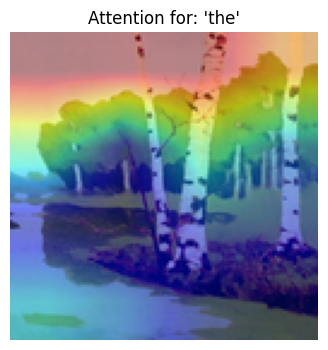

  Word 7: trees


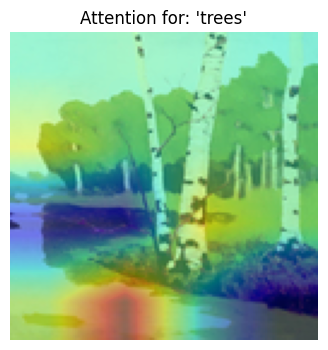

  Word 8: are


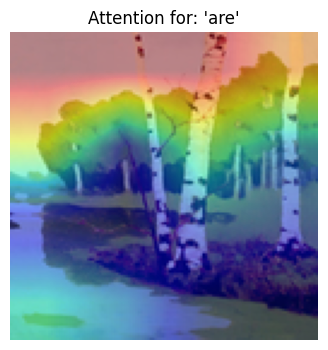

  Word 9: very


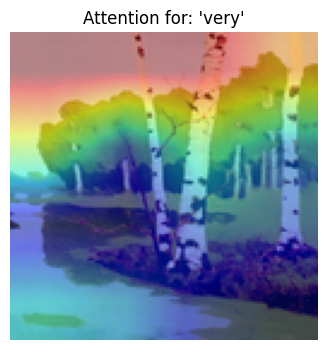

  Word 10: gloomy


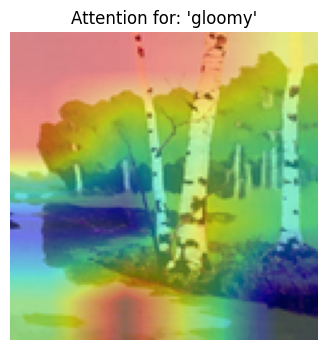

In [30]:
PAINTING = "arkhip-kuindzhi_birches-1879"  
EMOTION_ID = 6                             

# 0 amusement, 1 contentment, 2 awe, 3 excitement,
# 4 fear, 5 anger, 6 sadness, 7 disgust, 8 "something else"

attention_visualiser.visualize_sample(
    embedding_type="glove",    # choose embedding type
    csv_path="new_preprocessed/artemis_preprocessed.csv",
    features_root="new_preprocessed/features",
    checkpoint_root="new_checkpoints",
    painting=PAINTING,
    emotion_id=EMOTION_ID,
    max_words=20,               
)

[INFO] Loading VLT models into cache (first run only)...
  - loading VLT-glove from new_checkpoints/glove/m2_glove_best.pt
  - loading VLT-fasttext from new_checkpoints/fasttext/m2_fasttext_best.pt
[INFO] Loading CNN+LSTM models into cache (first run only)...
  - loading CNN-glove from eval_outputs/results_cnn_lstm/best_model_glove.pth
  - loading CNN-fasttext from eval_outputs/results_cnn_lstm/best_model_fasttext.pth
  - loading CNN-tfidf from eval_outputs/results_cnn_lstm/best_model_tfidf.pth

Processing: test.jpg | Emotion: 1 (contentment)


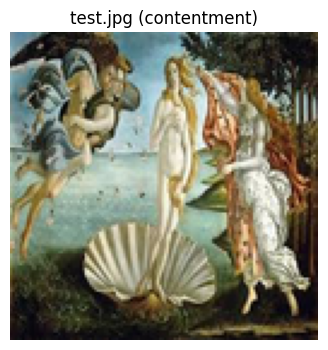

------------------------------------------------------------
VLT (Transformer) predictions:
[VLT-glove]   the woman looks like she is enjoying a nice day
[VLT-fasttext]   the man is sitting on the window and the woman looks like a <unk>
------------------------------------------------------------
CNN+LSTM predictions:
[CNN-glove]   the colors are very calming and the colors are very calming
[CNN-fasttext]   the woman is very happy and the colors are very calming
[CNN-tfidf]   the woman is in a woman 's face and the woman is very happy
------------------------------------------------------------


In [31]:
%matplotlib inline

import sys
import importlib

sys.path.append("scripts")
sys.path.append(".")

import scripts.viva_predict

importlib.reload(scripts.viva_predict)

# Emotion IDs {
#     0: "amusement", 1: "contentment", 2: "awe", 3: "excitement",
#     4: "fear", 5: "anger", 6: "sadness", 7: "disgust", 8: "something else"}

IMAGE_NAME = "test.jpg"      
EMOTION_ID = 1               

scripts.viva_predict.predict_single_image(
    image_name=IMAGE_NAME,
    emotion_id=EMOTION_ID,
    images_root="viva_images"
)

***

## <span style="background-color:yellow; color:black">TASK 7: Analysis and Discussion</span>

***



***

## <span style="background-color:yellow; color:black">TASK 8: Conclusion </span>

***
write here only

***

## <span style="background-color:yellow; color:black">TASK 9: Reference</span>

***
1. CNN models for Image Captioning: https://www.researchgate.net/publication/355978058_Comparison_of_Different_CNN_Model_used_as_Encoders_for_Image_Captioning
2. Embeddings and vectors: https://medium.com/@saschametzger/what-are-tokens-vectors-and-embeddings-how-do-you-create-them-e2a3e698e037 
3. How to subtokenize: https://www.geeksforgeeks.org/nlp/subword-tokenization-in-nlp/
4. TF-IDF functions: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
5. Glove vectors: https://nlp.stanford.edu/projects/glove/
6. FastText: https://fasttext.cc
7. FastText working: https://www.geeksforgeeks.org/machine-learning/fasttext-working-and-implementation/
8. How to image caption generate: https://medium.com/@khaledeemam/a-step-by-step-guide-to-building-an-image-caption-generator-using-tensorflow-a9e0a87cc0cb
9. Batch Sizehttps://www.sciencedirect.com/science/article/pii/S2405959519303455
10. Image Captioning: https://github.com/stha1122/Image_Caption_Generator/blob/main/image-caption-generator-using-cnn-lstm.ipynb
11. CNN + LSTM for image captioning: https://data-flair.training/blogs/python-based-project-image-caption-generator-cnn/
12. Artemis Research Paper: https://openaccess.thecvf.com/content/CVPR2021/papers/Achlioptas_ArtEmis_Affective_Language_for_Visual_Art_CVPR_2021_paper.pdf
